In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

In [2]:
masers = pd.read_csv('/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/w51_irs2_ammonia_maser_spectral_spatial_fits.csv')
sources = pd.read_csv('/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/FK5_ICRS_offsets/offset_sources.csv')

In [38]:
#fig, ax = plt.subplots(figsize=(8, 8))

CA3_vlsr = masers[(masers['source'] == 'CA3')]['vlsr_kms']
CA3_vlsr_err = masers[(masers['source'] == 'CA3')]['vlsr_kms_err']

CA3_x = masers[(masers['source'] == 'CA3')]['x_mean_sky']
CA3_y = masers[(masers['source'] == 'CA3')]['y_mean_sky']

CA3_ALMA_x_sky = sources[((sources['source'] == 'CA3') & (sources['freq'] == '90 GHz'))]['x_mean_sky']
CA3_ALMA_y_sky = sources[((sources['source'] == 'CA3') & (sources['freq'] == '90 GHz'))]['y_mean_sky']

delta_y = float(CA3_ALMA_y_sky) - CA3_y
delta_x = float(CA3_ALMA_x_sky) - CA3_x

distance_from_CA3 = np.sqrt(delta_x**2 + delta_y**2) * u.deg.to(u.arcsec)
print(f"Distance from CA3 to ALMA: {distance_from_CA3} ")


Distance from CA3 to ALMA: 0    0.005620
1    0.004221
2    0.005117
3    0.002364
4    0.005697
5    0.005697
8    0.005998
dtype: float64 


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_74626/4045692303.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  delta_y = float(CA3_ALMA_y_sky) - CA3_y
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_74626/4045692303.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  delta_x = float(CA3_ALMA_x_sky) - CA3_x


In [ ]:
# CA3_vlsr = CA3_vlsr[(distance_from_CA3 > 0.05)]
# CA3_vlsr_err = CA3_vlsr_err[(distance_from_CA3 > 0.05)]
# distance_from_CA3 = distance_from_CA3[(distance_from_CA3 > 0.05)]


Text(0, 0.5, 'VLSR (km/s)')

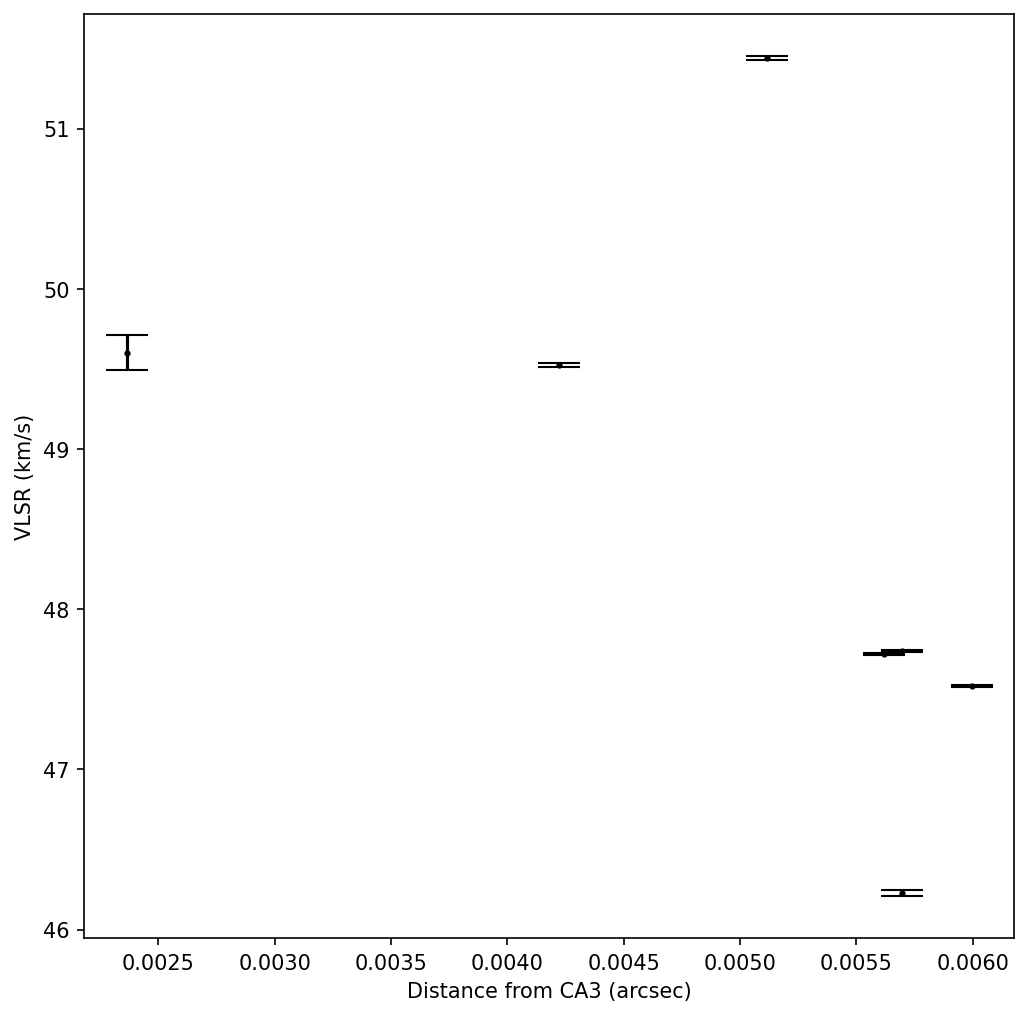

In [39]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

ax.errorbar(distance_from_CA3, CA3_vlsr, yerr=CA3_vlsr_err, marker='o', color='black',markersize=2, linestyle='none', capsize=10)
ax.set_xlabel('Distance from CA3 (arcsec)')
ax.set_ylabel('VLSR (km/s)')